# Week 6 — challenger rules (Wednesday, 1 hour)

Six exercises on fc-10's `challengers` module and Decision 4. All numbers are computed by fc-10's own code on the
seeded population, and every rate is **PLANTED TRUTH**. Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
ch = fc10_module("runtime.manufacturing.tuning.challengers")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")
sns.set_theme(style="whitegrid")

pop = tm_sim.generate()
[d4] = [e for e in decision_log.load() if e["decision_id"] == "D4"]
ev = d4["evidence"]
print(d4["decision"], d4["challenger_verdicts"])

HOLD {'amount_and_velocity': 'REJECT', 'relative_spike': 'ADVANCE_TO_VALIDATION'}


## Exercise 1 — the comparison Decision 4 was made on

Every rule on the **hold-out**, at the champion's workload.

In [2]:
rows = {"champion (£75k)": {**ev["champion"]["hold_out"], "only this rule": None}}
for kind, c in ev["challengers"].items():
    rows[kind] = {**c["hold_out"], "only this rule": c["hold_out"]["overlap"]["challenger_only"]}
pd.DataFrame(rows).T[["workload", "customers_alerted", "tp", "caught_per_100_reviews", "only this rule"]]

,workload,customers_alerted,tp,caught_per_100_reviews,only this rule
champion (£75k),2601.0,707.0,122.0,4.69,NaN
amount_and_velocity,1519,536,88,5.79,0
relative_spike,2253,1845,170,7.55,63


## Exercise 2 — why the velocity challenger lost

It needs a burst: several payments in 7 days. Compare the 7-day payment count at the **planted spike payments**
with every other payment. If the planted behaviour had bursts, the planted distribution would sit to the right.

,mean,50%,max
planted spike,,,
False,1.699197,1.0,8.0
True,1.974093,2.0,6.0


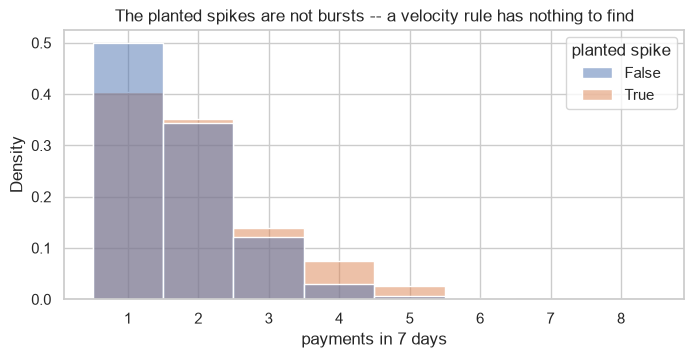

In [3]:
vel = ch.features(pop, {"kind": "amount_and_velocity", "window_days": 7})
v = pd.DataFrame([{"payments in 7 days": f, "planted spike": t.planted} for t, f in vel])
display(v.groupby("planted spike")["payments in 7 days"].describe()[["mean", "50%", "max"]])
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(v, x="payments in 7 days", hue="planted spike", stat="density", common_norm=False, discrete=True, ax=ax)
ax.set(title="The planted spikes are not bursts -- a velocity rule has nothing to find")
plt.show()

The planted spikes do sit a little higher -- a median of 2 payments in 7 days against 1 -- because a customer's 1-3 spikes
land in the same month and sometimes the same week. That is a hint, not a burst: Decision 4's rationale says the planted
behaviour has no bursts, which measured is slightly too strong, and the log keeps what was decided rather than being rewritten.

## Exercise 3 — an alert that explains itself

One customer only the challenger catches: their payments, their own baseline, and the line the rule fires above.

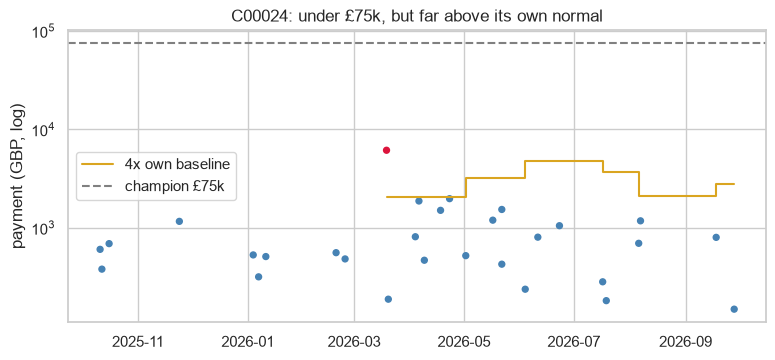

2026-03-19 payment 6,119.15 is 12.0x this customer's baseline (median of the previous 3 months); the rule fires above 4x and above 0


In [4]:
spec = ev["challengers"]["relative_spike"]["spec"]
champ_caught = set(ch.evaluate(pop, ch.champion())["caught"])
only = [c for c in ch.evaluate(pop, spec)["caught"] if c not in champ_caught]
cid = only[0]
feats = [(t, f) for t, f in ch.features(pop, spec) if t.customer_id == cid]
hist = pd.DataFrame([{"date": pd.Timestamp(t.value_date), "amount": t.amount,
                      "baseline": (t.amount / f) if f else None, "planted": t.planted} for t, f in feats])
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.scatter(hist.date, hist.amount, c=np.where(hist.planted, "crimson", "steelblue"), s=18)
ax.step(hist.date, hist.baseline * spec["multiple"], where="post", c="goldenrod", label=f"{spec['multiple']}x own baseline")
ax.axhline(75_000, ls="--", c="grey", label="champion £75k")
ax.set(yscale="log", ylabel="payment (GBP, log)", title=f"{cid}: under £75k, but far above its own normal")
ax.legend(); plt.show()
for r in ch.explain(pop, spec, cid):
    print(r["value_date"], r["reason"])

Notice where the gold line starts: nowhere before the customer has five payments in the previous three months. Before
that there is no baseline, and a spike there would be invisible to this rule -- the cold start, in one picture.

## Exercise 4 — same work, different customers

Per alerted customer, the challenger's precision is lower. Per unit of work, its yield is higher. Both are true.

In [5]:
rows = {}
for name, s in (("champion", ch.champion()), ("customer baseline", spec)):
    r = ch.evaluate(pop, s)
    rows[name] = {"workload (customer-months)": r["workload"], "distinct customers": r["customers_alerted"],
                  "caught": r["tp"], "precision per customer": r["precision"],
                  "caught per 100 reviews": round(100 * r["tp"] / r["workload"], 2)}
pd.DataFrame(rows).T

,workload (customer-months),distinct customers,caught,precision per customer,caught per 100 reviews
champion,2419.0,679.0,110.0,0.162003,4.55
customer baseline,2286.0,1887.0,161.0,0.085321,7.04


## Exercise 5 — who each rule catches (hold-out)

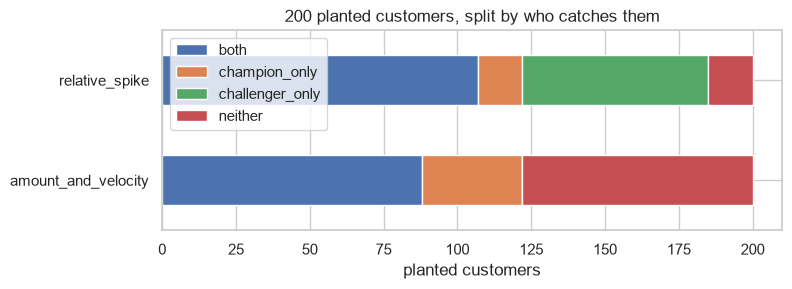

,both,challenger_only,champion_only,neither
amount_and_velocity,88,0,34,78
relative_spike,107,63,15,15


In [6]:
o = pd.DataFrame({k: c["hold_out"]["overlap"] for k, c in ev["challengers"].items()}).T
o[["both", "champion_only", "challenger_only", "neither"]].plot.barh(stacked=True, figsize=(8, 2.6))
plt.title("200 planted customers, split by who catches them"); plt.xlabel("planted customers"); plt.show()
o

## Exercise 6 — the two honesty checks

The negative control keeps the labels and removes the behaviour; the cold start counts planted customers who spike
before they have a baseline.

In [7]:
rs = ev["challengers"]["relative_spike"]
print("negative control lift (want ~1):", rs["negative_control"]["lift"])
print("planted customers the baseline rule cannot see (cold start):", rs["cold_start_planted"])
print()
print(ev["caveat"])

negative control lift (want ~1): 0.9342
planted customers the baseline rule cannot see (cold start): 49

relative_spike mirrors how the planted value_spike was generated (a spike relative to the customer's own scale), so planted truth favours it by construction; a win shows the rule can catch what was planted, not that it beats the champion on real behaviour.


## Your answers (the curriculum's success criteria)

1. **Does the customer-baseline challenger merit further validation? Why, in numbers?**

    *…*

2. **What would validation have to show before it replaced the champion?** Use Exercises 4 and 6.

    *…*

3. **Why was amount-and-velocity rejected, and when would you try it again?** Use Exercise 2.

    *…*